In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("/Users/AlanHDLR/Desktop")

In [135]:
# Importamos y leemos la Base de Datos
data = pd.read_csv("recursos_humanos.csv")
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [137]:
# Re-codificamos las variables categóricas
# Lista de columnas que quieres codificar
import pandas as pd

columnas_categoricas = ['sales', 'salary']

# Aplicamos pd.get_dummies, para las columnas categoricas
# El probelma era que la tabla resulatante me mostraba valores booleanos
data_codificada = pd.get_dummies(data, columns = columnas_categoricas)

# Convertimos todas las columnas booleanas a tipo entero para que muestren valores entre 0 y 1.
# True se convierte en 1 y False se convierte en 0.
columnas_booleanas = data_codificada.select_dtypes(include=['bool']).columns
data_codificada[columnas_booleanas] = data_codificada[columnas_booleanas].astype(int)

data_codificada

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,160,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,143,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14997,0.11,0.96,6,280,4,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0


In [139]:
# Obtenemos los valores de la variable "left"
# Variable 1 que se encarga de obtener todos los empleados que dejan la empresa
# Variable 0 para los empleados que se quedan
se_queda = data_codificada[data_codificada.left == 0]
se_va = data_codificada[data_codificada.left == 1]

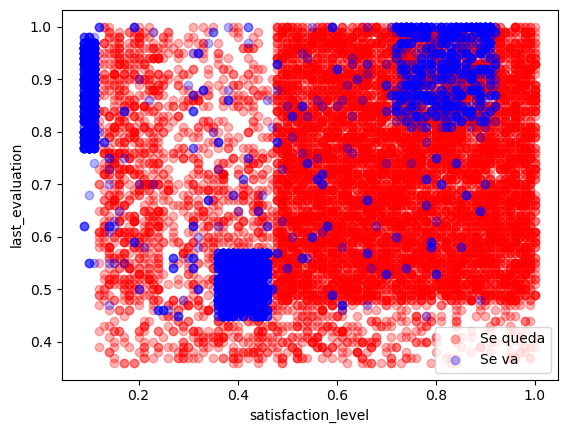

In [183]:
# Diagrama de dispersion entre "satisfaction_level" y "last_evaluation"
plt.scatter(se_queda.satisfaction_level, se_queda.last_evaluation, color = "red", label = "Se queda", alpha = 0.3)
plt.scatter(se_va.satisfaction_level, se_va.last_evaluation, color = "blue", label = "Se va", alpha = 0.3)
plt.xlabel("satisfaction_level")
plt.ylabel("last_evaluation")
plt.legend()
plt.show()

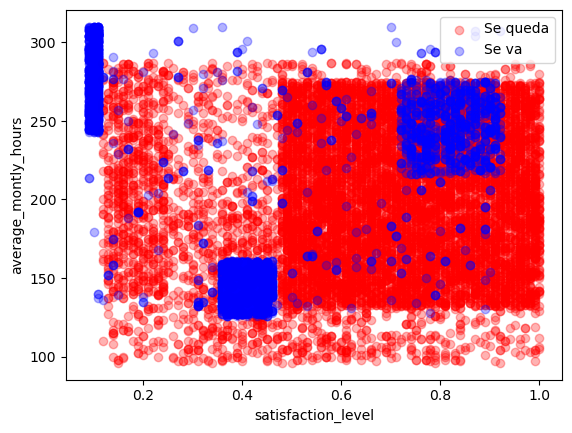

In [185]:
# Diagrama de dispersion entre "average_montly_hours" y "satisfaction_level"
plt.scatter(se_queda.satisfaction_level, se_queda.average_montly_hours, color = "red", label = "Se queda", alpha = 0.3)
plt.scatter(se_va.satisfaction_level, se_va.average_montly_hours, color = "blue", label = "Se va", alpha = 0.3)
plt.xlabel("satisfaction_level")
plt.ylabel("average_montly_hours")
plt.legend()
plt.show()

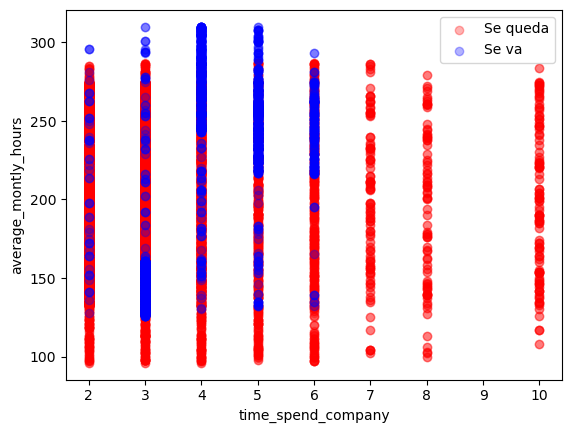

In [187]:
# Diagrama de dispersion entre "time_spend_company" y "average_montly_hours"
plt.scatter(se_queda.time_spend_company, se_queda.average_montly_hours, color = "red", label = "Se queda", alpha = 0.3)
plt.scatter(se_va.time_spend_company, se_va.average_montly_hours, color = "blue", label = "Se va", alpha = 0.3)
plt.xlabel("time_spend_company")
plt.ylabel("average_montly_hours")
plt.legend()
plt.show()

# Explicación
### Despues dew analizar las 3 graficas y determinar que la mayor cantidad de empleados se van mientras se cumpla 1 o mas de las siguintes 3 condiciones:
### - Mayor sea el número de horas que trabajan
### - Mas bajo sea su nivel de satisfacción  
### - Mejor sea su evaluación dentro de la empresa
### Tome la desición de tomar la tabla que relaciona los valores del nivel de satisfacción y las horas trabajadas

In [149]:
# Creamos nuestra base de entrenamiento y prueba 
y = data_codificada.left.values
x_data = data_codificada.drop(["left"], axis = 1)

In [151]:
y

array([1, 1, 1, ..., 1, 1, 1], dtype=int64)

In [153]:
x_data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,160,3,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,143,3,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
14997,0.11,0.96,6,280,4,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0


In [155]:
# Necesitamos homologar valores para que las escalas coincidan 
# Normalizamos 
x = x = (x_data - x_data.min()) / (x_data.max() - x_data.min())
x

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.318681,0.265625,0.0,0.285047,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.780220,0.781250,0.6,0.775701,0.500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.021978,0.812500,1.0,0.822430,0.250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.692308,0.796875,0.6,0.593458,0.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.307692,0.250000,0.0,0.294393,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.340659,0.328125,0.0,0.257009,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
14995,0.307692,0.187500,0.0,0.299065,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
14996,0.307692,0.265625,0.0,0.219626,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
14997,0.021978,0.937500,0.8,0.859813,0.250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [157]:
# Separacion de bases de prueba y entrenamiento 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.30, random_state = 1)

# Notas
### - Despues de hacer varias pruebas en cuento al numero de vecinos, si bien al usar la tecnica de la raiz cuadrada se obtuvo un valor redondeado de 121, cuando se usaba este número de vecinos, la precisión disminuia significativamente al 87%
### - Probando diferentes valores, descubri que los valores en un rango entre 2 y 20 me daban valores superiores al 90%
### - Si bien la mejor presición me la daba un valor de 2, esta tambien aumentaba el número de falsos negativos y lo que queremos es que este sea el valor con menor cantidad.
### - Despues de probar varios valores, el número 3 me dio una presicion del 0.9453333333333334 y la menor cantidad de falsos negativos.

In [282]:
# Modelo KNN (K vecinos mas cercanos)
from sklearn.neighbors import KNeighborsClassifier
# Alusion al numero de vecinos mas cercaanos 
knn = KNeighborsClassifier(n_neighbors = 20)
# Ajuste de las bases de entrenamiento para X y Y
knn.fit(x_train, y_train)
prediction = knn.predict(x_test)
print("Score: ", knn.score(x_test, y_test))

Score:  0.9188888888888889


In [283]:
y_pred = prediction
y_true = y_test

In [286]:
# Creacion de la matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
cm

array([[3246,  170],
       [ 195,  889]], dtype=int64)

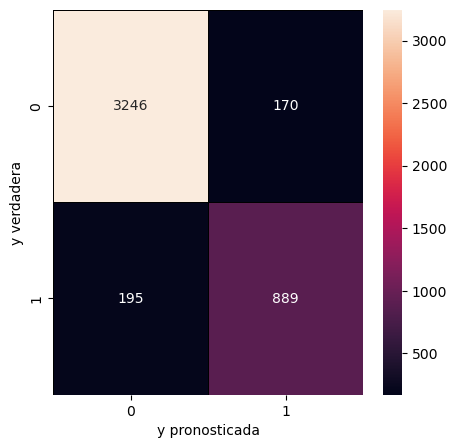

In [288]:
# Visualizacion de la matriz de confusión
import seaborn as sns
f, ax = plt.subplots(figsize = (5,5))

sns.heatmap(cm, annot = True, linewidths = 0.5, linecolor = "black", fmt = ".0f", ax = ax)
plt.xlabel("y pronosticada")
plt.ylabel("y verdadera")
plt.show()

# (1 = Sí, 0 = No).

In [169]:
# Calculo de la presicion global
Correctos = cm[0,0] + cm[1,1]
Incorrectos = cm[0,1] + cm[1,0]
PresicionGlobal = Correctos / (Correctos + Incorrectos)
PresicionGlobal

0.9453333333333334

In [171]:
Presicion_se_queda = cm[0,0] / (cm[0,0] + cm[1,0])
Presicion_se_queda

0.9751199040767387

In [173]:
Presicion_se_va = cm[1,1] / (cm[1,1] + cm[0,1])
Presicion_se_va

0.8599656357388317

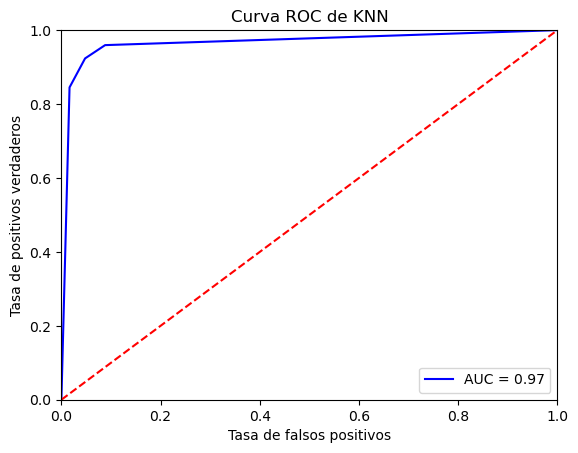

In [181]:
# Comnparamos si la tasa de positivos verdaderos es mas grande que la de falsos positivos
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_scores = knn.predict_proba(x_test)

fpr, tpr, threshold = roc_curve(y_test, y_scores[:,1])
# fpr = False positive rate, tpr = True positive rate
# Calculamos el area bajo la curva
roc_auc = auc(fpr, tpr)

# 0.2f = dos decimales
plt.title("Receiver Operating Characteristics")
plt.plot(fpr, tpr, "b", label = "AUC = %0.2F" % roc_auc)
plt.legend(loc = "lower right")
plt.plot([0,1], [ 0,1], "r--")
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel("Tasa de positivos verdaderos")
plt.xlabel("Tasa de falsos positivos")
plt.title("Curva ROC de KNN")
plt.show()
# La curva nos refleja la tasa de positivos verdaderos